In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import requests
from matplotlib import pyplot as plt
from scipy import stats

from scripts.utils import *
from census import Census
from scripts.census_preprocessing import *
from scripts.cdc_places_preprocessing import *
from scripts.analysis import *

nyc_counties = [36005, 36047, 36061, 36081, 36085]

# set to false  to cache data
load_acs_data = False
load_dec_data = False
load_cdc_places_data = False
load_hvi = False
print_all_nri = False

rank_method = "min"  # average is alternative
correlation_method = "spearman"  # alternatives are pearson or kendalls tau

# parameters for spatial joins
spatial_join_method = "representative_point"  # alternatives: centroid, representative_point, spatial_overlap

In [2]:
# Set up defaults for plotting
markers = ["D", "^", "o"]

# Data Setup and Cleaning

## Load geospatial data

In [3]:
# census tract to nta crosswalk
# set all crs to EPSG:2263 ("NAD83 / New York Long Island (ftUS)")
nyc_open_data_path = (
    "https://data.cityofnewyork.us/resource"  # default path for accessing open data
)
nta_geo, zcta_geo, tract_geo, boros_geo = load_geospatial(
    nyc_open_data_path, nyc_counties
)
nyc_modzcta = load_modzcta(nyc_open_data_path)
nta_xwalk = load_nta_xwalk(nyc_open_data_path, tract_geo)

------------------------
Loading NTA data
There are 262 unique neighborhoods
------------------------
Loading ZCTA data
Number of unique ZCTAs 215
There are 215 unique ZCTAs
------------------------
Loading NYC Census Tracts
There are 2325 unique tracts
------------------------
Loading NYC Boroughs
There are 5 unique boroughs
------------------------
Loading MODZCTA data from DOHMH
There are 2 unmerged tracts: 36047990100, 36081990100
There are 2325 unique tracts (for all NTAs)


## Load HVI data

In [4]:
df_hvi_zcta, df_hvi_nta = load_hvi_data(
    nyc_open_data_path, zcta_geo, nta_geo, load_data=load_hvi
)

------------------------
Loading HVI (ZCTA) data
There are 184 unique ZCTAs in the data
------------------------
Loading HVI (NTA) data
Data size: (197, 14)
There are 197 unique NTAs in the data


## Load ACS and Census data (i.e., sociodemographics)

In [5]:
acs_gdf, acs_zcta_gdf, dec_gdf = load_census(
    tract_geo, zcta_geo, load_acs_data=load_acs_data, load_dec_data=load_dec_data
)

Data size: (2325, 183)
Unmerged: 11439, 11249
Data size: (215, 177)
Data size: (2325, 22)


In [6]:
acs_gdf_hvi = clean_acs_hvi(acs_gdf)

Number of values < 0 for median_hhinc is: 86


## Load the National Risk Index Data (NRI)

In [7]:
df_nri = load_nri_data(nyc_counties, download_nri_data=False)

------------------------
Loading NRI data (tract-level)
There are 2324 unique ZCTAs in the data
Renaming columns and ranking


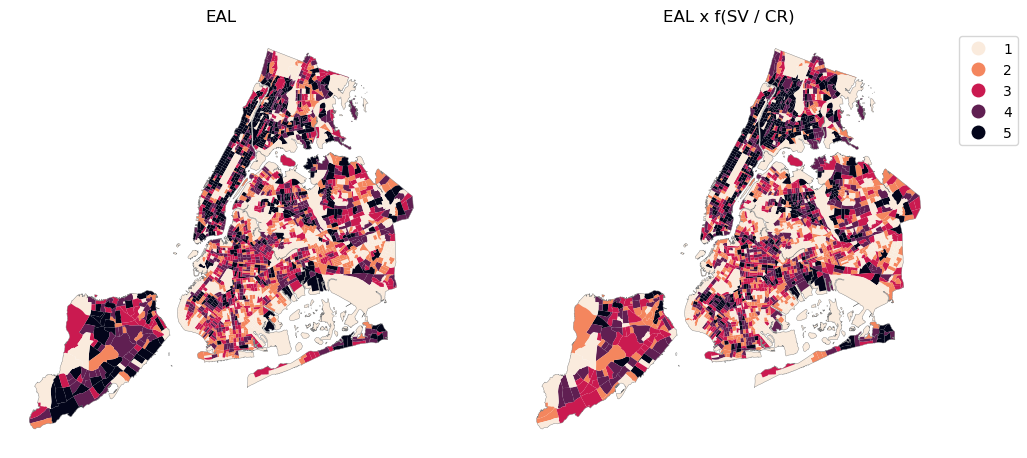

In [8]:
plot_nri(df_nri, tract_geo, boros_geo)

In [9]:
heatwave_vars = [x for x in df_nri.columns if ("Heat" in x) | ("HWAV" in x)]
for var in heatwave_vars:
    if pd.api.types.is_string_dtype(df_nri[var]):
        df_nri[var] = np.select(
            [
                df_nri[var] == "Very Low",
                df_nri[var] == "Relatively Low",
                df_nri[var] == "Relatively Moderate",
                df_nri[var] == "Relatively High",
                df_nri[var] == "Very High",
            ],
            [1, 2, 3, 4, 5],
            0,
        )

if print_all_nri:
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    tract_geo[["geoid", "geometry"]].merge(df_nri, on="geoid").plot(
        column=var, cmap="rocket_r", ax=ax, edgecolor="none", legend=True
    )
    boros_geo.plot(ax=ax, facecolor="none", edgecolor="gray", lw=0.3)

    ax.set_title(var)
    ax.axis("off")

    plt.savefig(
        f"./_figures/nri plots/nri_plot_{var}.pdf",
        bbox_inches="tight",
        pad_inches=0,
        dpi=300,
    )
    plt.show()

### Load URI Data

In [10]:
gdf_uri = load_uri()

In [11]:
if print_all_nri:
    heatwave_vars = [x for x in gdf_uri.columns if "EXHR_" in x]
    for var in heatwave_vars:
        if pd.api.types.is_string_dtype(gdf_uri[var]):
            gdf_uri[var] = np.select(
                [
                    gdf_uri[var] == "Very Low",
                    gdf_uri[var] == "Relatively Low",
                    gdf_uri[var] == "Relatively Moderate",
                    gdf_uri[var] == "Relatively High",
                    gdf_uri[var] == "Very High",
                ],
                [1, 2, 3, 4, 5],
                0,
            )
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        gdf_uri.plot(column=var, cmap="rocket_r", ax=ax, edgecolor="none", legend=True)
        boros_geo.plot(ax=ax, facecolor="none", edgecolor="gray", lw=0.3)

        ax.set_title(var)
        ax.axis("off")

        plt.savefig(
            f"./_figures/uri plots/uri_plot_{var}.pdf",
            bbox_inches="tight",
            pad_inches=0,
            dpi=300,
        )
        plt.show()

## Load CDC Places Data

In [352]:
df_cdc, df_cdc_zcta = load_cdc_places(
    zcta_geo, nyc_counties, year=2024, load_cdc_places_data=load_cdc_places_data
)

------------------------
Loading CDC Places Data


In [353]:
df_cdc_wide = clean_cdc_places(df_cdc, id_var="geoid")

------------------------
Cleaning CDC Places Data
id var = geoid
Number of unique health measures: 15
Conditions:                                                measure   measureid
3                                 Obesity among adults     OBESITY
7                                  Stroke among adults      STROKE
98      No leisure-time physical activity among adults         LPA
104                        Current asthma among adults     CASTHMA
108  Taking medicine to control high blood pressure...       BPMED
109                   Mobility disability among adults    MOBILITY
112                Coronary heart disease among adults         CHD
115  High cholesterol among adults who have ever be...    HIGHCHOL
117                    Diagnosed diabetes among adults    DIABETES
121  Chronic obstructive pulmonary disease among ad...        COPD
141              Frequent mental distress among adults       MHLTH
212                   High blood pressure among adults      BPHIGH
240            

In [354]:
df_cdc_wide_zcta = clean_cdc_places(df_cdc_zcta, id_var="zcta")

------------------------
Cleaning CDC Places Data
id var = zcta
Number of unique health measures: 15
Conditions:                                                   measure   measureid
331222                                Stroke among adults      STROKE
331944                   High blood pressure among adults      BPHIGH
331945  Taking medicine to control high blood pressure...       BPMED
331947                        Current asthma among adults     CASTHMA
331948                Coronary heart disease among adults         CHD
331950                 Cholesterol screening among adults  CHOLSCREEN
331953  Chronic obstructive pulmonary disease among ad...        COPD
331957                    Diagnosed diabetes among adults    DIABETES
331961  High cholesterol among adults who have ever be...    HIGHCHOL
331963     No leisure-time physical activity among adults         LPA
331965              Frequent mental distress among adults       MHLTH
331966                   Mobility disability am

## Load CDC HHI Data

In [355]:
import sys, importlib

importlib.reload(sys.modules["scripts.cdc_places_preprocessing"])
from scripts.cdc_places_preprocessing import *

load_cdc_hhi_from_url()
df_cdc_hhi_geo, df_cdc_hhi_tract = load_and_clean_hhi(
    zcta_geo, tract_geo, join_method=spatial_join_method, rank_method=rank_method
)

------------------------
Loading CDC HHI Data
------------------------
Loading and cleaning CDC HHI Data
Data size: (185, 80)
Producing tract -> ZCTA spatial join (for comparisons)
Merged data size: (2325, 82)
Tract data size: (2325, 14)
ZCTA data size: (185, 80)


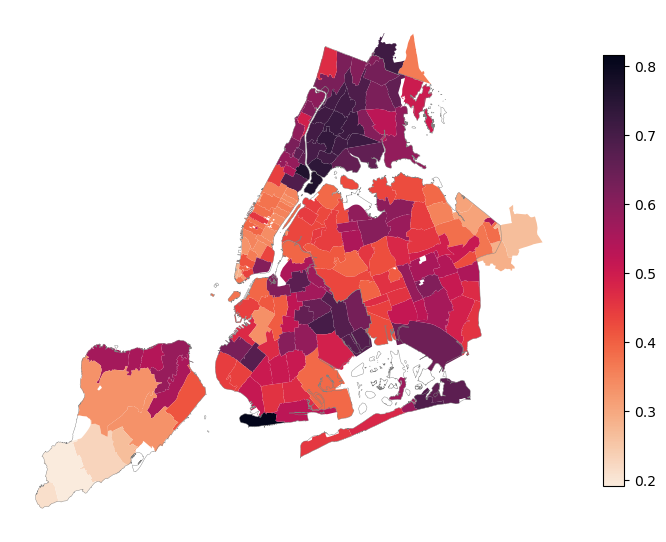

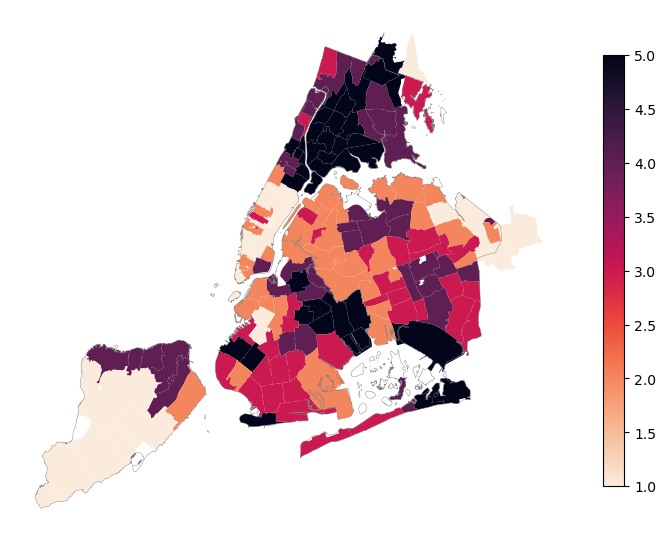

In [356]:
plot_simple_map(df_cdc_hhi_geo, boros_geo, "OVERALL_SCORE", "cdc_hhi_raw.pdf")
plot_simple_map(df_cdc_hhi_geo, boros_geo, "OVERALL_SCORE_q5", "cdc_hhi.pdf")

## Load ECOSTRESS Data

In [357]:
lst_tract = load_ecostress_data("avg_lst_20250730.geojson")
lst_nta = load_ecostress_data(
    "lst_20250730_vectorized_nta.geojson", id_col="NTA2020"
).rename(columns={"NTA2020": "nta2020"})

------------------------
Loading ECOSTRESS land surface temperature
Data size: (2325, 10)
------------------------
Loading ECOSTRESS land surface temperature
Data size: (262, 10)


## Load Vegetation

In [358]:
veg_tract = load_veg_data("zonal_hist.csv", rank_method=rank_method)
veg_nta = load_veg_data(
    "zonal_hist_nta.csv", rank_method=rank_method, id_col="nameAlt"
).rename(columns={"nameAlt": "nta2020"})

------------------------
Loading vegetation data
Data size: (2325, 112)
------------------------
Loading vegetation data
Data size: (262, 14)


## Combine ACS, CDC, and Vegetation at Census Tract Level

In [359]:
print(acs_gdf_hvi.shape)
df_mgd = merge_dfs(acs_gdf_hvi, veg_tract, lst_tract, df_cdc_wide, id_col="geoid")
df_mgd.isna().mean().sort_values(ascending=False).head(10)

(2292, 34)
------------------------
Merging datasets together
ACS data size: 2292
Merged data size: 2292


pct_hh_gt65                0.027487
data_value_STROKE_total    0.026614
data_value_STROKE          0.026614
data_value_BPHIGH          0.026614
data_value_BPMED           0.026614
data_value_CASTHMA         0.026614
data_value_CHD             0.026614
data_value_CHOLSCREEN      0.026614
data_value_COPD            0.026614
data_value_DIABETES        0.026614
dtype: float64

## Produce NTA Summary of Data

In [360]:
health_cdc_cols = [
    x
    for x in df_cdc_wide.columns
    if (("data_value" in x) and ("_total") in x) | ("totalpop" in x.lower())
]
len(health_cdc_cols)

df_nta_summary = produce_nta_summary(
    df_mgd, acs_pop_vars + dec_pop_vars + age_vars + health_cdc_cols
)

------------------------
Producing NTA summary from tract data
Number of NTAs: (246, 40)


In [361]:
df_nta_summary.head()

,nta2020,totalpop,poverty_status_inpoverty,inpoverty_75over_male,inpoverty_75over_female,hh_gt65,total_hh_age,total_over75,black,totalpop_dec,...,data_value_COPD_total,data_value_DIABETES_total,data_value_HIGHCHOL_total,data_value_LPA_total,data_value_MHLTH_total,data_value_MOBILITY_total,data_value_OBESITY_total,data_value_PHLTH_total,data_value_SELFCARE_total,data_value_STROKE_total
0,BK0101,34503.0,3515.0,70.0,440.0,3289.0,16743.0,1980.0,1072.0,38980.0,...,997.484,1761.407,8287.405485,5454.512,5002.748,2154.849,7594.658,2736.875,602.257,536.625
1,BK0102,59410.0,8830.0,341.0,396.0,3185.0,25874.0,1813.0,3050.0,64444.0,...,1707.953,3276.107,12069.420156,10655.854,8679.892,4195.266,12578.069,5016.175,1363.907,939.563
2,BK0103,45664.0,22987.0,217.0,325.0,2552.0,10563.0,1489.0,1618.0,47703.0,...,2731.998,2981.908,6569.472637,9452.768,6235.765,5223.631,7846.088,4947.231,2136.292,1209.239
3,BK0104,51688.0,13242.0,191.0,535.0,4895.0,22307.0,2981.0,8249.0,52998.0,...,2359.874,4676.427,11901.202430,13030.339,8076.211,6305.285,12131.562,6022.299,2193.249,1409.064
4,BK0201,23874.0,1074.0,25.0,151.0,3035.0,11506.0,1680.0,1248.0,25092.0,...,646.093,1272.493,5948.619054,3066.919,2647.054,1449.035,4244.242,1597.003,340.372,392.246


## Load HVI at NTA Level

In [542]:
df_hvi_analysis = df_hvi_nta.merge(df_nta_summary, on="nta2020", how="left")
df_hvi_analysis = produce_pct(df_hvi_analysis)

print(f"Data size: {df_hvi_analysis.shape}")
df_hvi_analysis, health_cdc_pct_cols = cdc_nta_cleaning(
    df_hvi_analysis, health_cdc_cols
)
health_zscore_cols = [
    x + "_z" for x in health_cdc_pct_cols if x not in ["data_value_MHLTH_pct", "data_value_CHOLSCREEN_pct", "data_value_LPA_pct",]] # "data_value_CHOLSCREEN_pct", "data_value_BPMED_pct",   

Data size: (197, 60)


In [543]:
health_zscore_cols

['data_value_BPHIGH_pct_z',
 'data_value_BPMED_pct_z',
 'data_value_CASTHMA_pct_z',
 'data_value_CHD_pct_z',
 'data_value_COPD_pct_z',
 'data_value_DIABETES_pct_z',
 'data_value_HIGHCHOL_pct_z',
 'data_value_MOBILITY_pct_z',
 'data_value_OBESITY_pct_z',
 'data_value_PHLTH_pct_z',
 'data_value_SELFCARE_pct_z',
 'data_value_STROKE_pct_z']

In [544]:
# merge in lst and vegetation
df_mgd_nta = merge_dfs(df_hvi_analysis, veg_nta, lst_nta, None, id_col="nta2020")

print("\nMissing value %:")
df_mgd_nta.isna().mean().sort_values(ascending=False).head(10)

------------------------
Merging datasets together
ACS data size: 197
Merged data size: 197

Missing value %:


nta2020                      0.0
GEONAME                      0.0
data_value_CHOLSCREEN_pct    0.0
data_value_CHD_pct           0.0
data_value_CASTHMA_pct       0.0
data_value_BPMED_pct         0.0
data_value_BPHIGH_pct        0.0
nonwhite_nh_dec_pct          0.0
pct_over_75                  0.0
pct_over65                   0.0
dtype: float64

# Analysis

## Visualize all index Tools

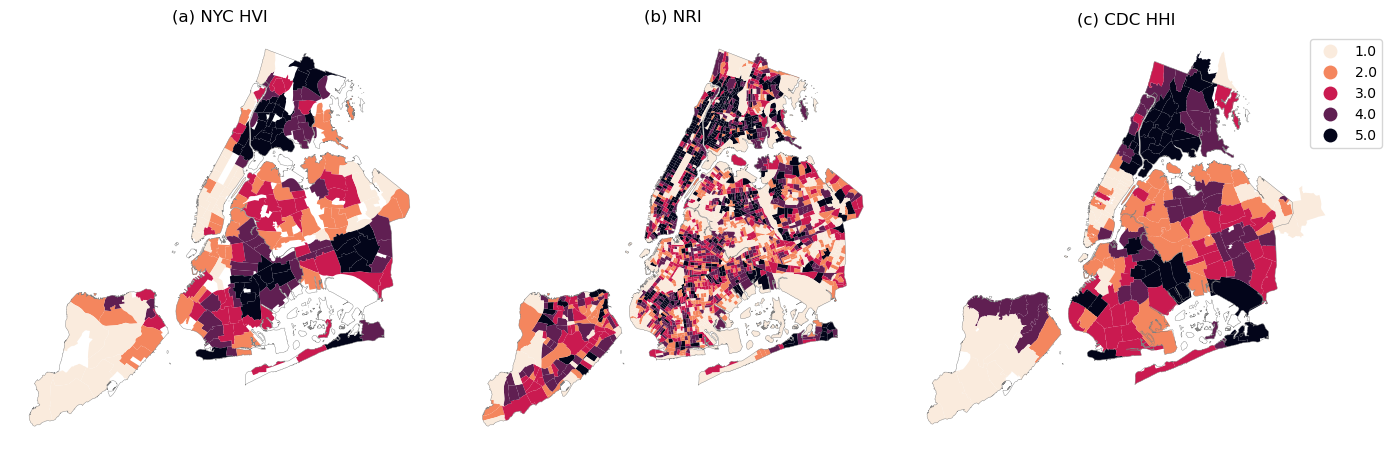

In [545]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
nta_geo[["geometry", "nta2020"]].merge(df_hvi_analysis).plot(
    column="HVI_RANK",
    ax=axes[0],
    cmap="rocket_r",
    legend=False,
    edgecolor="none",
)
tract_geo.merge(df_nri).plot(
    column="HWAV_EALTxSVIxRESL_q5",
    cmap="rocket_r",
    ax=axes[1],
    legend=False,
    edgecolor="none",
)

axes[1].set_title("(b) NRI")
df_cdc_hhi_geo["OVERALL_SCORE_q5"] = df_cdc_hhi_geo["OVERALL_SCORE_q5"].astype(str)
df_cdc_hhi_geo.plot(
    column="OVERALL_SCORE_q5",
    ax=axes[2],
    cmap="rocket_r",
    edgecolor="none",
    legend=True,
    legend_kwds={"loc": "upper right", "bbox_to_anchor": (1.1, 1)},
)
axes[0].set_axis_off()
axes[1].set_axis_off()
axes[2].set_axis_off()

# axes[0].set_title("Original HVI")
axes[0].set_title("(a) NYC HVI")
axes[2].set_title("(c) CDC HHI")

boros_geo.plot(ax=axes[0], facecolor="none", edgecolor="gray", lw=0.3)
boros_geo.plot(ax=axes[1], facecolor="none", edgecolor="gray", lw=0.3)
boros_geo.plot(ax=axes[2], facecolor="none", edgecolor="gray", lw=0.3)
plt.savefig(
    "./_figures/all_index_tools.pdf", bbox_inches="tight", pad_inches=0, dpi=300
)
plt.tight_layout()
plt.show()

## HVI Replication

In [546]:
vars_hvi = [
    "SURFACE_TEMP",
    "MEDIAN_INCOME",
    "GREENSPACE",
    "PCT_HOUSEHOLDS_AC",
    "PCT_BLACK_POP",
    "pct_hh_gt65",
    "pct_inpoverty_75over",
    "pct_over_75",
    "pct_inpoverty",
    "pct_over65",
    "nonwhite_nh_dec_pct",
]

df_hvi_analysis = df_hvi_analysis.copy()

In [547]:
# ensure in all the columns, we are only keeping are z-scores
cols_to_keep = [
    x + "_z" for x in vars_hvi + health_cdc_pct_cols + ["avg_cdc_health_vars"]
] + ["HVI_RANK", "nta2020"]

df_alt_specifications = standardize_values(
    df_hvi_analysis,
    vars_hvi + health_cdc_pct_cols + ["avg_cdc_health_vars"],
    rank_method=rank_method,
)[cols_to_keep].copy()

In [548]:
# produce all of the alternatiive specifications
alt_specifications = [
    "HVI_raw",
    "HVI_env",
    "HVI_age",
    "HVI_health",
    "HVI_all",
    "HVI_health_alt",
    "HVI_all_alt",
    "HVI_min",
]
df_alt_specifications = produce_all_specifications(
    df_alt_specifications, health_zscore_cols
)
gdf_alt_spec = rank_all_specifications(
    df_alt_specifications, nta_geo, alt_specifications, rank_method
)

------------------------
Producing all specifications
Reproducing original
Producing environmental only
Producing age and poverty prioritized
Producing health comorbidities added
Producing all (combined)
Producing minority status instead of race
Producing comorbidities (with average)
Producing all (with averaged comorbidities)
------------------------
Ranking all specifications
Producing alt specification for HVI_raw
Producing alt specification for HVI_env
Producing alt specification for HVI_age
Producing alt specification for HVI_health
Producing alt specification for HVI_all
Producing alt specification for HVI_health_alt
Producing alt specification for HVI_all_alt
Producing alt specification for HVI_min

Comparing differences between original and replicated HVI score
HVI_RANK  HVI_raw_q5
5         5.0           40
4         4.0           39
3         3.0           39
2         2.0           38
1         1.0           37
2         1.0            2
3         2.0            1
4         

## Correlation Analyses

In [549]:
produce_correlations(gdf_alt_spec, alt_specifications, "pearson")

------------------------
Correlation using pearson
\begin{tabular}{lllllllll}
\toprule
 & HVI_raw & HVI_env & HVI_age & HVI_health & HVI_all & HVI_health_alt & HVI_all_alt & HVI_min \\
\midrule
HVI_raw & 1.0 & 0.674 & 0.868 & 0.821 & 0.803 & 0.984 & 0.938 & 0.964 \\
HVI_env & 0.674 & 1.0 & 0.693 & 0.357 & 0.339 & 0.602 & 0.532 & 0.692 \\
HVI_age & 0.868 & 0.693 & 1.0 & 0.78 & 0.789 & 0.865 & 0.91 & 0.869 \\
HVI_health & 0.821 & 0.357 & 0.78 & 1.0 & 0.998 & 0.907 & 0.946 & 0.803 \\
HVI_all & 0.803 & 0.339 & 0.789 & 0.998 & 1.0 & 0.891 & 0.945 & 0.786 \\
HVI_health_alt & 0.984 & 0.602 & 0.865 & 0.907 & 0.891 & 1.0 & 0.974 & 0.956 \\
HVI_all_alt & 0.938 & 0.532 & 0.91 & 0.946 & 0.945 & 0.974 & 1.0 & 0.916 \\
HVI_min & 0.964 & 0.692 & 0.869 & 0.803 & 0.786 & 0.956 & 0.916 & 1.0 \\
\bottomrule
\end{tabular}



,HVI_raw,HVI_env,HVI_age,HVI_health,HVI_all,HVI_health_alt,HVI_all_alt,HVI_min
HVI_raw,1.000000,0.673926,0.868033,0.821384,0.802541,0.984241,0.938370,0.964108
HVI_env,0.673926,1.000000,0.692519,0.356954,0.338622,0.602238,0.532104,0.691926
HVI_age,0.868033,0.692519,1.000000,0.779573,0.789089,0.864999,0.909907,0.868506
HVI_health,0.821384,0.356954,0.779573,1.000000,0.997759,0.907333,0.946289,0.802937
HVI_all,0.802541,0.338622,0.789089,0.997759,1.000000,0.891451,0.945072,0.785879
HVI_health_alt,0.984241,0.602238,0.864999,0.907333,0.891451,1.000000,0.974019,0.955886
HVI_all_alt,0.938370,0.532104,0.909907,0.946289,0.945072,0.974019,1.000000,0.915769
HVI_min,0.964108,0.691926,0.868506,0.802937,0.785879,0.955886,0.915769,1.000000


In [550]:
rank_vars = [x + "_rank" for x in alt_specifications]
corr_rankings = produce_correlations(gdf_alt_spec, rank_vars, correlation_method)
corr_rankings

------------------------
Correlation using spearman
\begin{tabular}{lllllllll}
\toprule
 & HVI_raw_rank & HVI_env_rank & HVI_age_rank & HVI_health_rank & HVI_all_rank & HVI_health_alt_rank & HVI_all_alt_rank & HVI_min_rank \\
\midrule
HVI_raw_rank & 1.0 & 0.643 & 0.869 & 0.858 & 0.84 & 0.986 & 0.945 & 0.957 \\
HVI_env_rank & 0.643 & 1.0 & 0.673 & 0.4 & 0.381 & 0.588 & 0.524 & 0.667 \\
HVI_age_rank & 0.869 & 0.673 & 1.0 & 0.813 & 0.82 & 0.869 & 0.915 & 0.866 \\
HVI_health_rank & 0.858 & 0.4 & 0.813 & 1.0 & 0.997 & 0.923 & 0.955 & 0.826 \\
HVI_all_rank & 0.84 & 0.381 & 0.82 & 0.997 & 1.0 & 0.907 & 0.953 & 0.809 \\
HVI_health_alt_rank & 0.986 & 0.588 & 0.869 & 0.923 & 0.907 & 1.0 & 0.975 & 0.951 \\
HVI_all_alt_rank & 0.945 & 0.524 & 0.915 & 0.955 & 0.953 & 0.975 & 1.0 & 0.913 \\
HVI_min_rank & 0.957 & 0.667 & 0.866 & 0.826 & 0.809 & 0.951 & 0.913 & 1.0 \\
\bottomrule
\end{tabular}



,HVI_raw_rank,HVI_env_rank,HVI_age_rank,HVI_health_rank,HVI_all_rank,HVI_health_alt_rank,HVI_all_alt_rank,HVI_min_rank
HVI_raw_rank,1.000000,0.642921,0.868778,0.857843,0.839719,0.986429,0.945351,0.956539
HVI_env_rank,0.642921,1.000000,0.673215,0.399548,0.381131,0.588013,0.523728,0.667158
HVI_age_rank,0.868778,0.673215,1.000000,0.813033,0.820401,0.869265,0.914629,0.865752
HVI_health_rank,0.857843,0.399548,0.813033,1.000000,0.997233,0.922721,0.954801,0.825685
HVI_all_rank,0.839719,0.381131,0.820401,0.997233,1.000000,0.907245,0.953247,0.809097
HVI_health_alt_rank,0.986429,0.588013,0.869265,0.922721,0.907245,1.000000,0.974751,0.950516
HVI_all_alt_rank,0.945351,0.523728,0.914629,0.954801,0.953247,0.974751,1.000000,0.912885
HVI_min_rank,0.956539,0.667158,0.865752,0.825685,0.809097,0.950516,0.912885,1.000000


In [551]:
q5_vars = [x + "_q5" for x in alt_specifications]
corr_quintiles = produce_correlations(gdf_alt_spec, q5_vars, correlation_method)
corr_quintiles

------------------------
Correlation using spearman
\begin{tabular}{lllllllll}
\toprule
 & HVI_raw_q5 & HVI_env_q5 & HVI_age_q5 & HVI_health_q5 & HVI_all_q5 & HVI_health_alt_q5 & HVI_all_alt_q5 & HVI_min_q5 \\
\midrule
HVI_raw_q5 & 1.0 & 0.596 & 0.843 & 0.828 & 0.818 & 0.962 & 0.911 & 0.929 \\
HVI_env_q5 & 0.596 & 1.0 & 0.631 & 0.38 & 0.358 & 0.568 & 0.484 & 0.644 \\
HVI_age_q5 & 0.843 & 0.631 & 1.0 & 0.782 & 0.777 & 0.838 & 0.868 & 0.82 \\
HVI_health_q5 & 0.828 & 0.38 & 0.782 & 1.0 & 0.985 & 0.878 & 0.924 & 0.782 \\
HVI_all_q5 & 0.818 & 0.358 & 0.777 & 0.985 & 1.0 & 0.866 & 0.919 & 0.774 \\
HVI_health_alt_q5 & 0.962 & 0.568 & 0.838 & 0.878 & 0.866 & 1.0 & 0.934 & 0.919 \\
HVI_all_alt_q5 & 0.911 & 0.484 & 0.868 & 0.924 & 0.919 & 0.934 & 1.0 & 0.868 \\
HVI_min_q5 & 0.929 & 0.644 & 0.82 & 0.782 & 0.774 & 0.919 & 0.868 & 1.0 \\
\bottomrule
\end{tabular}



,HVI_raw_q5,HVI_env_q5,HVI_age_q5,HVI_health_q5,HVI_all_q5,HVI_health_alt_q5,HVI_all_alt_q5,HVI_min_q5
HVI_raw_q5,1.000000,0.595803,0.842704,0.827783,0.817611,0.962120,0.911356,0.928764
HVI_env_q5,0.595803,1.000000,0.631131,0.380383,0.357552,0.568064,0.484234,0.644465
HVI_age_q5,0.842704,0.631131,1.000000,0.782090,0.777085,0.837666,0.868343,0.819809
HVI_health_q5,0.827783,0.380383,0.782090,1.000000,0.984758,0.878322,0.923919,0.781833
HVI_all_q5,0.817611,0.357552,0.777085,0.984758,1.000000,0.865599,0.918817,0.774212
HVI_health_alt_q5,0.962120,0.568064,0.837666,0.878322,0.865599,1.000000,0.934059,0.918881
HVI_all_alt_q5,0.911356,0.484234,0.868343,0.923919,0.918817,0.934059,1.000000,0.867925
HVI_min_q5,0.928764,0.644465,0.819809,0.781833,0.774212,0.918881,0.867925,1.000000


In [552]:
def summarize_agreement(df, vars, latex=False):
    """Producing agreement summaries"""
    for var in vars:
        df[var + "_match"] = df[var + "_q5"] == df["HVI_raw_q5"]

    agreement_summary = (
        df[[x + "_match" for x in alt_specifications]].mean() * 100
    ).round(2)

    if latex == True:
        print(agreement_summary.to_latex())
    else:
        print(agreement_summary)
    return agreement_summary


agreement_summary = summarize_agreement(gdf_alt_spec, alt_specifications)

HVI_raw_match           100.00
HVI_env_match            32.49
HVI_age_match            55.33
HVI_health_match         47.21
HVI_all_match            46.19
HVI_health_alt_match     84.77
HVI_all_alt_match        67.51
HVI_min_match            71.57
dtype: float64


In [553]:
print(
    pd.concat(
        [
            corr_rankings.reset_index(drop=True),
            agreement_summary.reset_index(drop=True),
        ],
        axis=1,
        ignore_index=True,
    )
    .round(3)
    .astype(str)
    .to_latex()
)

\begin{tabular}{llllllllll}
\toprule
 & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 \\
\midrule
0 & 1.0 & 0.643 & 0.869 & 0.858 & 0.84 & 0.986 & 0.945 & 0.957 & 100.0 \\
1 & 0.643 & 1.0 & 0.673 & 0.4 & 0.381 & 0.588 & 0.524 & 0.667 & 32.49 \\
2 & 0.869 & 0.673 & 1.0 & 0.813 & 0.82 & 0.869 & 0.915 & 0.866 & 55.33 \\
3 & 0.858 & 0.4 & 0.813 & 1.0 & 0.997 & 0.923 & 0.955 & 0.826 & 47.21 \\
4 & 0.84 & 0.381 & 0.82 & 0.997 & 1.0 & 0.907 & 0.953 & 0.809 & 46.19 \\
5 & 0.986 & 0.588 & 0.869 & 0.923 & 0.907 & 1.0 & 0.975 & 0.951 & 84.77 \\
6 & 0.945 & 0.524 & 0.915 & 0.955 & 0.953 & 0.975 & 1.0 & 0.913 & 67.51 \\
7 & 0.957 & 0.667 & 0.866 & 0.826 & 0.809 & 0.951 & 0.913 & 1.0 & 71.57 \\
\bottomrule
\end{tabular}



### Compare to URI

In [554]:
# compare the HVI and the URI
uri_vars = ["EXHU_PN", "EXHU_SN", "EXHE_PXXT", "EXHE_SXXT", "EXHR_PTTTT", "EXHR_STTTT"]
gdf_hvi_uri_comp = gdf_alt_spec.merge(gdf_uri, on="nta2020")
gdf_hvi_uri_comp[["HVI_raw", "HVI_raw_rank", "HVI_raw_q5"] + uri_vars].corr()

,HVI_raw,HVI_raw_rank,HVI_raw_q5,EXHU_PN,EXHU_SN,EXHE_PXXT,EXHE_SXXT,EXHR_PTTTT,EXHR_STTTT
HVI_raw,1.000000,0.987936,0.956960,0.611686,0.551006,0.165913,0.094343,-0.038494,-0.071916
HVI_raw_rank,0.987936,1.000000,0.979796,0.623101,0.560247,0.164752,0.087458,-0.045762,-0.077476
HVI_raw_q5,0.956960,0.979796,1.000000,0.619972,0.549938,0.162698,0.087926,-0.050599,-0.076530
EXHU_PN,0.611686,0.623101,0.619972,1.000000,0.925065,0.347691,0.264585,-0.274376,-0.286973
EXHU_SN,0.551006,0.560247,0.549938,0.925065,1.000000,0.361664,0.282057,-0.277763,-0.295398
EXHE_PXXT,0.165913,0.164752,0.162698,0.347691,0.361664,1.000000,0.955196,-0.362504,-0.380925
EXHE_SXXT,0.094343,0.087458,0.087926,0.264585,0.282057,0.955196,1.000000,-0.339932,-0.351035
EXHR_PTTTT,-0.038494,-0.045762,-0.050599,-0.274376,-0.277763,-0.362504,-0.339932,1.000000,0.957017
EXHR_STTTT,-0.071916,-0.077476,-0.076530,-0.286973,-0.295398,-0.380925,-0.351035,0.957017,1.000000


------------------------
Prepping data for plotting
id var: nta2020
vars to pivot: EXHU
Data size: (197, 219)
Plotting EXHU
df temp size: (197, 8)
------------------------
Prepping data for plotting
id var: nta2020
vars to pivot: EXHU
Data size: (197, 219)
Plotting EXHU
df temp size: (197, 8)


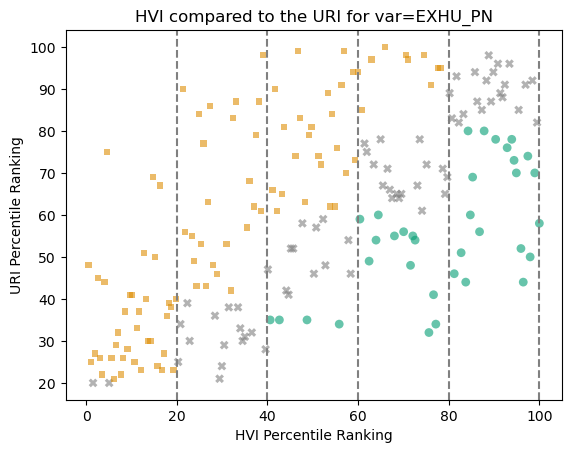

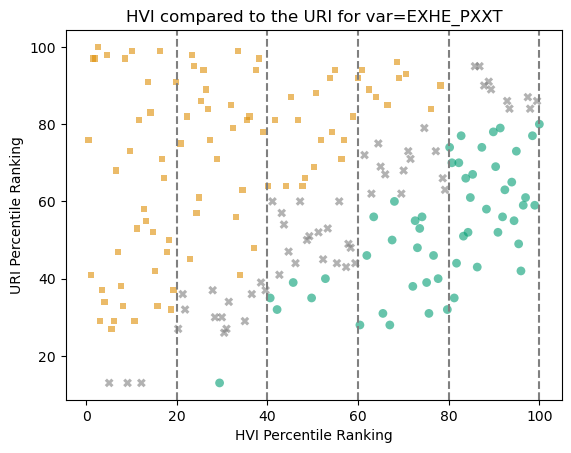

In [555]:
for var in ["EXHU_PN", "EXHE_PXXT"]:
    gdf_hvi_uri_plt = gdf_hvi_uri_comp.copy()
    gdf_hvi_uri_plt["EXHU_q5"] = np.select(
        [
            gdf_hvi_uri_plt[var] <= 20,
            gdf_hvi_uri_plt[var] <= 40,
            gdf_hvi_uri_plt[var] <= 60,
            gdf_hvi_uri_plt[var] <= 80,
            gdf_hvi_uri_plt[var] <= 100,
        ],
        [1, 2, 3, 4, 5],
        np.nan,
    )
    gdf_hvi_uri_plt = prep_for_plot(
        gdf_hvi_uri_plt.rename(columns={var: "EXHU_rank"}),
        ["EXHU"],
        "HVI_raw",
        "nta2020",
    )

    fig, ax = plt.subplots(1, 1)
    ax.axvline(20, color="gray", linestyle="dashed")
    ax.axvline(40, color="gray", linestyle="dashed")
    ax.axvline(60, color="gray", linestyle="dashed")
    ax.axvline(80, color="gray", linestyle="dashed")
    ax.axvline(100, color="gray", linestyle="dashed")
    produce_scatter(gdf_hvi_uri_plt, "HVI_raw", ax)
    ax.set_ylabel("URI Percentile Ranking")
    ax.set_xlabel("HVI Percentile Ranking")
    ax.set_title(f"HVI compared to the URI for var={var}")

### Compare replication to original

In [556]:
# check what's not merging
unmatched_filter = gdf_alt_spec["HVI_raw_q5"] != gdf_alt_spec["HVI_RANK"]
print(f"Number of NTAs not matching: {unmatched_filter.sum()}")
print(f"Number of NTAs matching: {(unmatched_filter == 0).sum()}")
gdf_alt_spec["unmatched"] = np.where(unmatched_filter, 1, 0)

Number of NTAs not matching: 4
Number of NTAs matching: 193


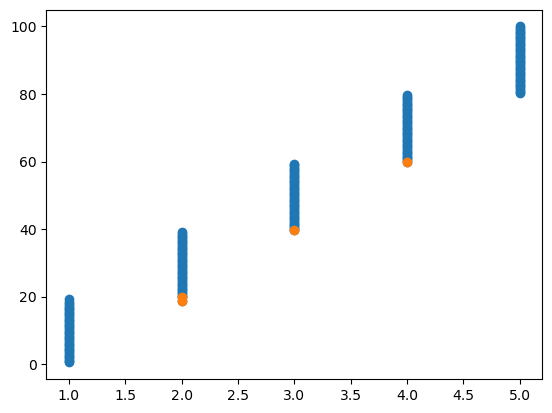

In [557]:
plt.scatter(
    gdf_alt_spec["HVI_RANK"].astype(float),
    gdf_alt_spec["HVI_raw_rank"],
    label="HVI original rankings X replicated",
)

plt.scatter(
    gdf_alt_spec[unmatched_filter]["HVI_RANK"].astype(float),
    gdf_alt_spec[unmatched_filter]["HVI_raw_rank"],
    label="Rankings do not match",
)
plt.show();

In [558]:
alt_specifications_without_original = [x for x in alt_specifications]

## Produce maps of differences in risk score prioritizations

In [559]:
gdf_alt_increases = compute_risk_increase(gdf_alt_spec, alt_specifications)

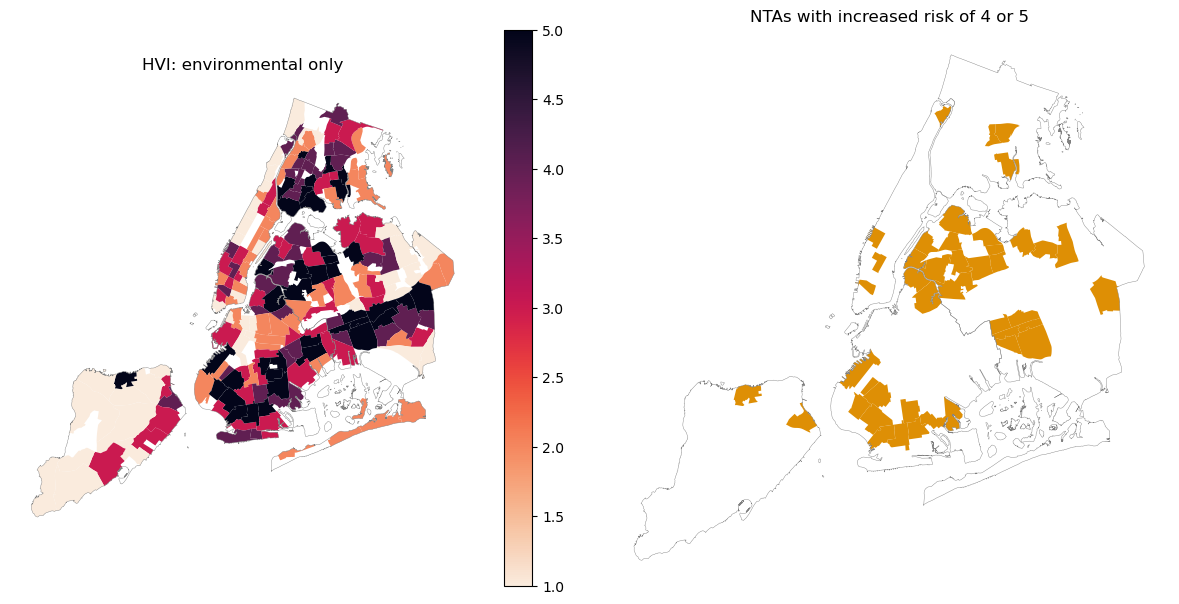

55                        Hunts Point
155               South Richmond Hill
165                           Jamaica
79                 Westchester Square
3                   East Williamsburg
156                Ozone Park (North)
127    Long Island City-Hunters Point
158                  South Ozone Park
14             East New York-New Lots
47             East Flatbush-Farragut
Name: ntaname, dtype: str


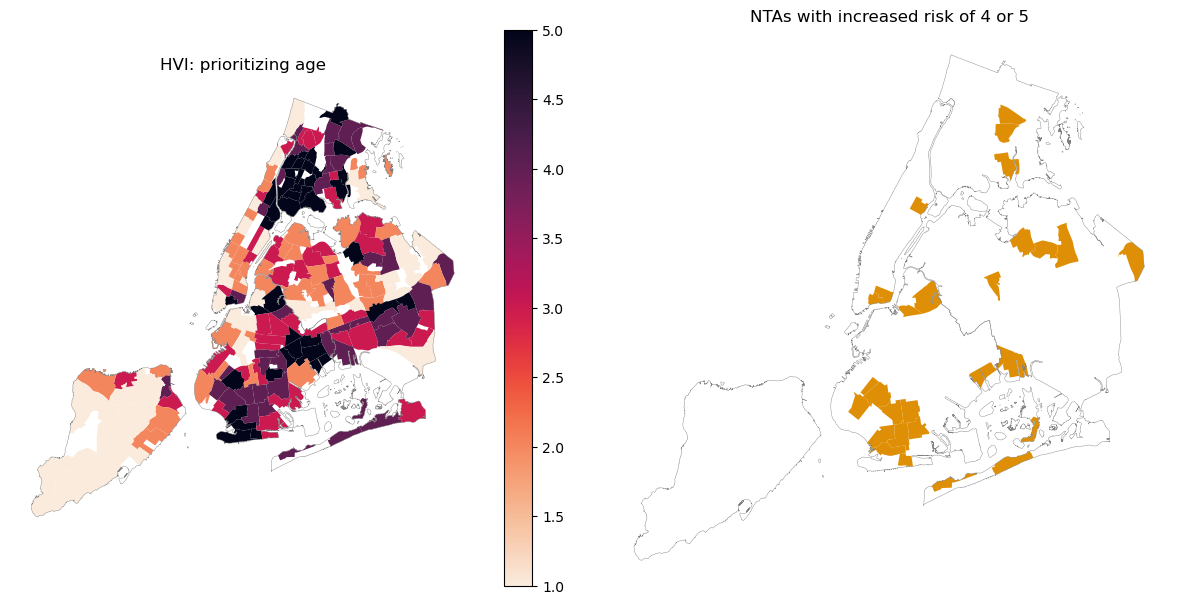

66                            West Farms
55                           Hunts Point
37                        Brighton Beach
67                               Tremont
36                 Coney Island-Sea Gate
59                     Crotona Park East
58    Claremont Village-Claremont (East)
45                           Brownsville
53                Mott Haven-Port Morris
57                            Morrisania
Name: ntaname, dtype: str


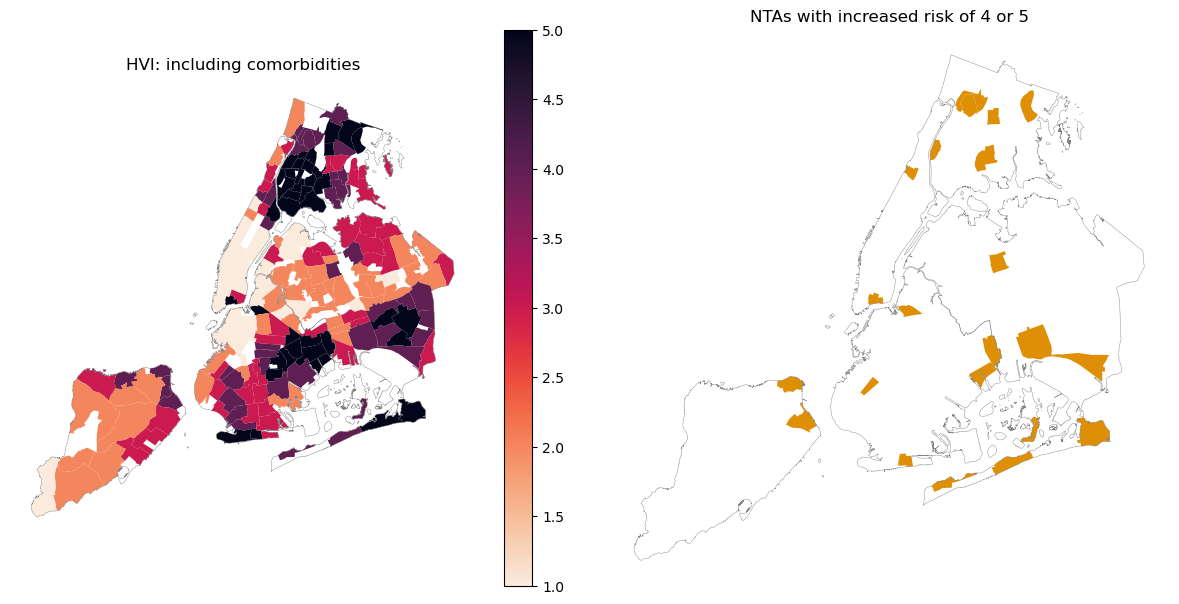

58    Claremont Village-Claremont (East)
66                            West Farms
45                           Brownsville
15            Spring Creek-Starrett City
53                Mott Haven-Port Morris
67                               Tremont
36                 Coney Island-Sea Gate
54                               Melrose
57                            Morrisania
59                     Crotona Park East
Name: ntaname, dtype: str


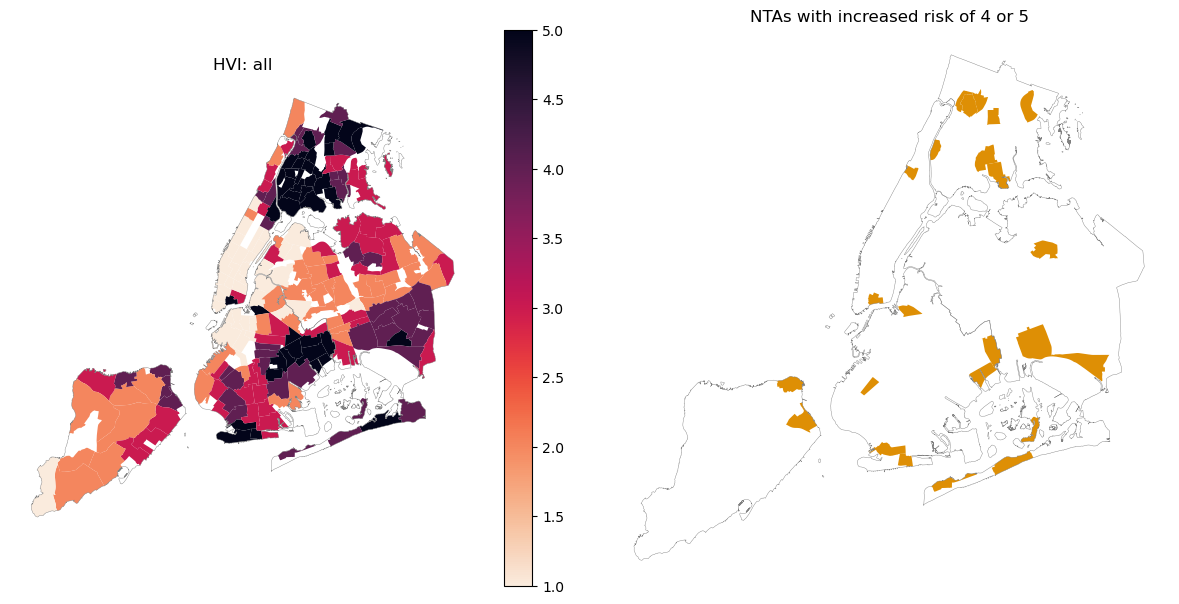

58    Claremont Village-Claremont (East)
66                            West Farms
45                           Brownsville
15            Spring Creek-Starrett City
36                 Coney Island-Sea Gate
53                Mott Haven-Port Morris
67                               Tremont
54                               Melrose
57                            Morrisania
59                     Crotona Park East
Name: ntaname, dtype: str


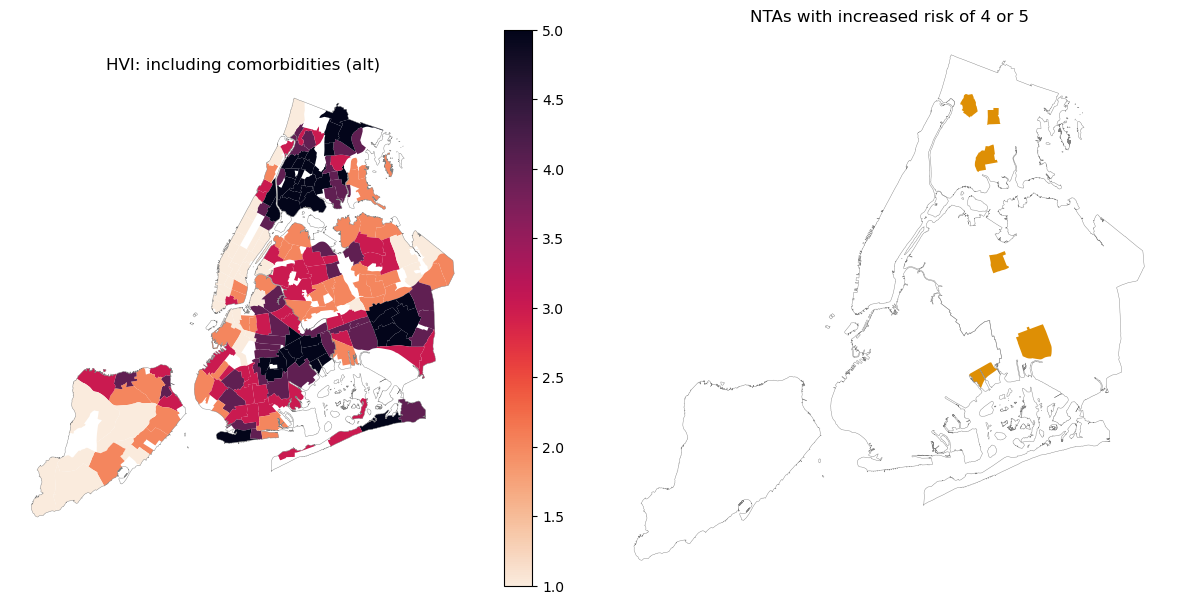

58    Claremont Village-Claremont (East)
45                           Brownsville
67                               Tremont
59                     Crotona Park East
66                            West Farms
57                            Morrisania
55                           Hunts Point
14                East New York-New Lots
53                Mott Haven-Port Morris
49          East Flatbush-Remsen Village
Name: ntaname, dtype: str


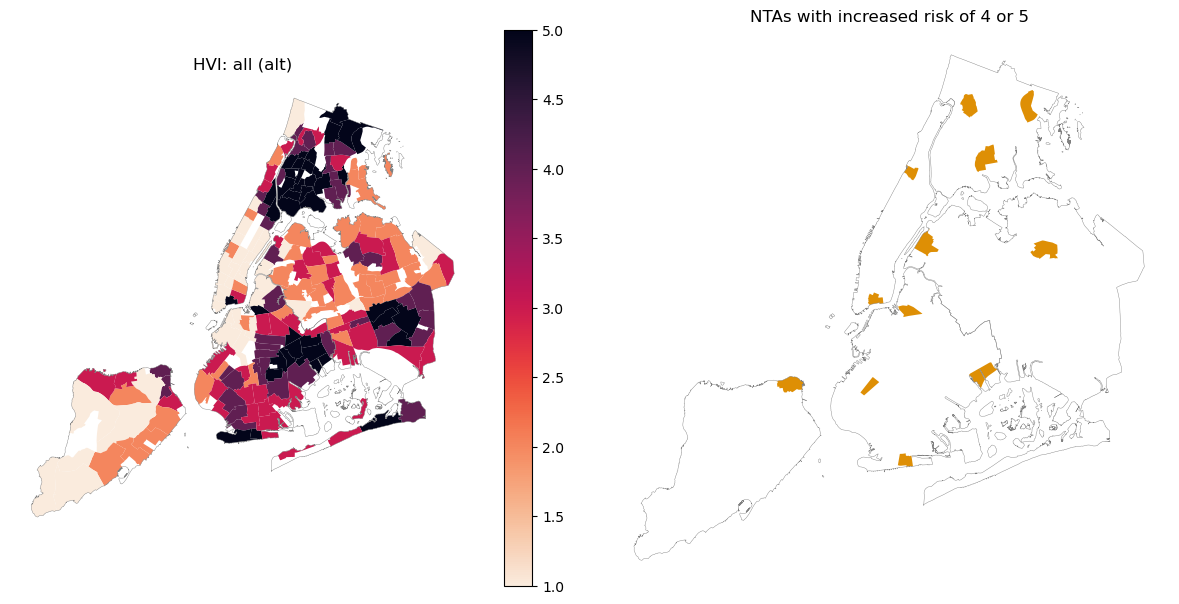

45                           Brownsville
66                            West Farms
58    Claremont Village-Claremont (East)
67                               Tremont
59                     Crotona Park East
15            Spring Creek-Starrett City
53                Mott Haven-Port Morris
57                            Morrisania
55                           Hunts Point
36                 Coney Island-Sea Gate
Name: ntaname, dtype: str


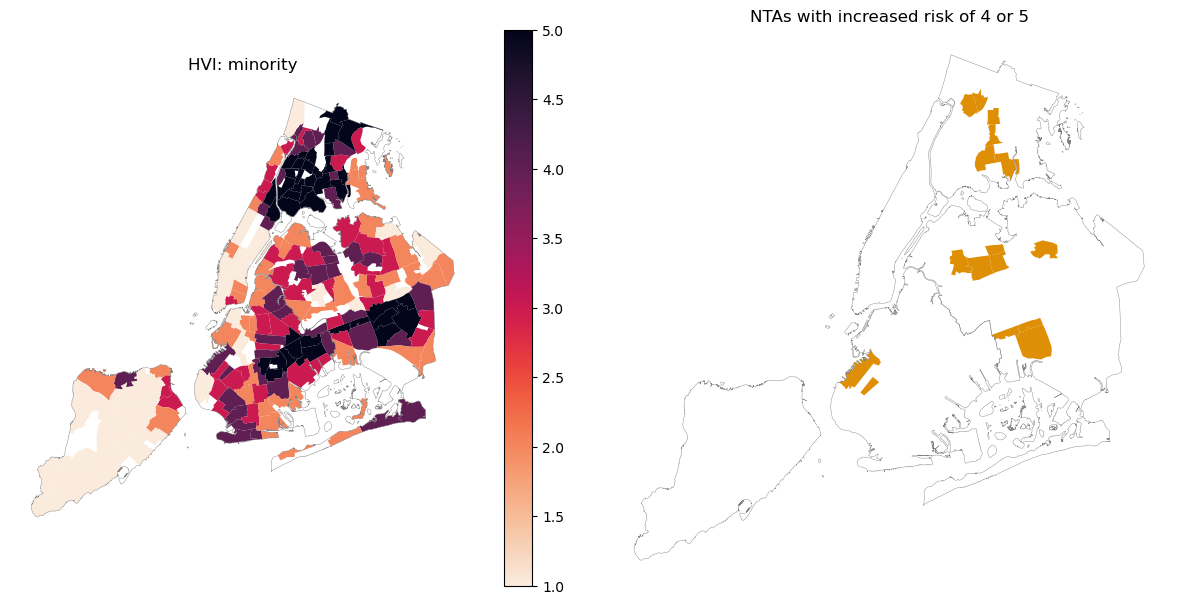

55                            Hunts Point
59                      Crotona Park East
67                                Tremont
58     Claremont Village-Claremont (East)
66                             West Farms
57                             Morrisania
64                             Mount Hope
53                 Mott Haven-Port Morris
165                               Jamaica
68                                Belmont
Name: ntaname, dtype: str


In [560]:
titles = [
    "HVI: environmental only",
    "HVI: prioritizing age",
    "HVI: including comorbidities",
    "HVI: all",
    "HVI: including comorbidities (alt)",
    "HVI: all (alt)",
    "HVI: minority",
]

produce_risk_increase_map(gdf_alt_increases, alt_specifications, boros_geo, titles)

## Produce NYC HVI at the census tract level

In [561]:
# produce NTA version with similar inputs that match (e.g., LST and % vegetation)
df_hvi_nta_tractrepl = standardize_values(
    df_mgd_nta,
    [
        "_mean_f",
        "pct_vegetation",
        "PCT_BLACK_POP",
        "MEDIAN_INCOME",
        "PCT_HOUSEHOLDS_AC",
    ],
    rank_method,
).copy()

df_hvi_nta_tractrepl["HVI_nta_orig"] = produce_hvi_alternatives(
    df_hvi_nta_tractrepl,
    ["_mean_f_z", "PCT_BLACK_POP_z"],
    ["pct_vegetation_z", "PCT_HOUSEHOLDS_AC_z", "MEDIAN_INCOME_z"],
)

df_hvi_nta_tractrepl["HVI_nta_orig_rank"], df_hvi_nta_tractrepl["HVI_nta_orig_q5"] = (
    custom_qcut_function(df_hvi_nta_tractrepl["HVI_nta_orig"], method=rank_method)
)

In [562]:
df_hvi_nta_tractrepl[["pct_vegetation", "GREENSPACE"]].corr(method=correlation_method)

,pct_vegetation,GREENSPACE
pct_vegetation,1.00000,0.99997
GREENSPACE,0.99997,1.00000


In [563]:
df_tract_hvi = merge_tract_nta(df_hvi_nta_tractrepl, df_mgd)

Data shape: (2292, 9)
After dropping missing AC values, data shape is: (2240, 9)


In [564]:
# produce NTA version with similar inputs that match (e.g., LST and % vegetation)
df_tract_hvi_alt_spec = standardize_values(
    df_tract_hvi,
    ["_mean_f", "pct_vegetation", "pct_black", "median_hhinc", "PCT_HOUSEHOLDS_AC"],
    rank_method,
).copy()

df_tract_hvi_alt_spec["HVI_tract"] = produce_hvi_alternatives(
    df_tract_hvi_alt_spec,
    ["_mean_f_z", "pct_black_z"],
    ["pct_vegetation_z", "PCT_HOUSEHOLDS_AC_z", "median_hhinc_z"],
)

df_tract_hvi_alt_spec["HVI_tract_rank"], df_tract_hvi_alt_spec["HVI_tract_q5"] = (
    custom_qcut_function(df_tract_hvi_alt_spec["HVI_tract"], method=rank_method)
)

In [565]:
# merge on NTA-level data
gdf_tract_hvi = (
    tract_geo[["geoid", "geometry"]]
    .merge(df_tract_hvi_alt_spec, on="geoid", how="inner")
    .merge(
        gdf_alt_spec[["nta2020", "HVI_raw_rank", "HVI_raw_q5"]],
        on="nta2020",
        how="left",
    )
    .merge(
        df_hvi_nta_tractrepl[
            [
                "nta2020",
                "HVI_nta_orig",
                "HVI_nta_orig_rank",
                "HVI_nta_orig_q5",
            ]
        ].drop_duplicates(),
        how="left",
        on="nta2020",
        suffixes=("", "_nta"),
    )
    .merge(df_nri, on="geoid", how='left')
)

In [566]:
gdf_tract_hvi[
    [
        "HVI_nta_orig_rank",
        "HVI_tract_rank",
        "HVI_raw_rank",
        "HVI_nta_orig_q5",
        "HVI_tract_q5",
    ]
    + [
        "HWAV_EALT_rank",
        "HWAV_EALTxSVIxRESL_rank",
        "HWAV_EALT_NatlPct",
        "HWAV_Score",
        "HWAV_Rating",
    ]
].corr(method=correlation_method)

,HVI_nta_orig_rank,HVI_tract_rank,HVI_raw_rank,HVI_nta_orig_q5,HVI_tract_q5,HWAV_EALT_rank,HWAV_EALTxSVIxRESL_rank,HWAV_EALT_NatlPct,HWAV_Score,HWAV_Rating
HVI_nta_orig_rank,1.000000,0.898710,0.939368,0.978900,0.880191,-0.039700,0.119520,-0.340086,0.119520,0.113366
HVI_tract_rank,0.898710,1.000000,0.857814,0.877428,0.979796,-0.012596,0.156720,-0.318021,0.156720,0.148506
HVI_raw_rank,0.939368,0.857814,1.000000,0.920263,0.841509,-0.089792,0.070079,-0.362463,0.070079,0.077011
HVI_nta_orig_q5,0.978900,0.877428,0.920263,1.000000,0.863091,-0.029602,0.123641,-0.341073,0.123641,0.117446
HVI_tract_q5,0.880191,0.979796,0.841509,0.863091,1.000000,-0.014722,0.147724,-0.304802,0.147724,0.141603
HWAV_EALT_rank,-0.039700,-0.012596,-0.089792,-0.029602,-0.014722,1.000000,0.924343,-0.298069,0.924343,0.818262
HWAV_EALTxSVIxRESL_rank,0.119520,0.156720,0.070079,0.123641,0.147724,0.924343,1.000000,-0.400580,1.000000,0.896899
HWAV_EALT_NatlPct,-0.340086,-0.318021,-0.362463,-0.341073,-0.304802,-0.298069,-0.400580,1.000000,-0.400580,-0.362472
HWAV_Score,0.119520,0.156720,0.070079,0.123641,0.147724,0.924343,1.000000,-0.400580,1.000000,0.896899
HWAV_Rating,0.113366,0.148506,0.077011,0.117446,0.141603,0.818262,0.896899,-0.362472,0.896899,1.000000


In [567]:
gdf_tract_hvi_summary = gdf_tract_hvi.groupby(["HVI_nta_orig_rank"], as_index=False)[
    "HVI_tract_rank"
].agg(["max", "min", "mean", "std"])
gdf_tract_hvi_summary

,HVI_nta_orig_rank,max,min,mean,std
0,0.507614,17.500000,0.044643,6.438492,6.561580
1,1.015228,2.991071,0.133929,1.183036,1.288471
2,1.522843,3.571429,0.089286,1.524235,1.487000
3,2.030457,7.455357,0.312500,3.934949,2.660958
4,2.538071,3.839286,0.625000,2.660714,1.239030
...,...,...,...,...,...
192,97.969543,99.419643,85.535714,95.545281,4.067994
193,98.477157,99.732143,95.535714,98.035714,1.222776
194,98.984772,99.910714,91.205357,97.315051,3.060281
195,99.492386,99.241071,97.276786,98.764881,0.641134


## Prep data for scatter plots / alternative specifications visualization

In [568]:
# tract level
gdf_tract_hvi_plt = prep_for_plot(gdf_tract_hvi, ["HVI_tract"], "HVI_nta_orig", "geoid")
gdf_tract_hvi_plt.head()

------------------------
Prepping data for plotting
id var: geoid
vars to pivot: HVI_tract
Data size: (2240, 506)


,geoid,rank,q5,variable,HVI_nta_orig_rank,HVI_nta_orig_q5,color,label
0,36061002201,52.366071,3.0,HVI_tract,48.730964,3.0,gray,Unchanged HVI score
1,36061002602,31.696429,2.0,HVI_tract,40.101523,3.0,#de8f05,Decreased HVI score
2,36061002800,53.973214,3.0,HVI_tract,40.101523,3.0,gray,Unchanged HVI score
3,36061003400,31.205357,2.0,HVI_tract,40.101523,3.0,#de8f05,Decreased HVI score
4,36061003601,46.428571,3.0,HVI_tract,48.730964,3.0,gray,Unchanged HVI score


In [569]:
# NTA level
gdf_nta_hvi_plt = prep_for_plot(
    gdf_alt_spec, ["HVI_env", "HVI_age", "HVI_health", "HVI_all"], "HVI_raw", "nta2020"
)
gdf_nta_hvi_plt.head()

------------------------
Prepping data for plotting
id var: nta2020
vars to pivot: HVI_env, HVI_age, HVI_health, HVI_all
Data size: (197, 81)


,nta2020,rank,q5,variable,HVI_raw_rank,HVI_raw_q5,color,label
0,BK0101,72.588832,4.0,HVI_env,36.548223,2.0,#029e73,Increased HVI score
1,BK0102,47.715736,3.0,HVI_env,24.365482,2.0,#029e73,Increased HVI score
2,BK0103,79.695431,4.0,HVI_env,66.497462,4.0,gray,Unchanged HVI score
3,BK0104,97.969543,5.0,HVI_env,73.096447,4.0,#029e73,Increased HVI score
4,BK0201,6.598985,1.0,HVI_env,5.076142,1.0,gray,Unchanged HVI score


In [570]:
gdf_nta_hvi_plt["label"].value_counts(normalize=True)

label
Unchanged HVI score    0.453046
Increased HVI score    0.279188
Decreased HVI score    0.267766
Name: proportion, dtype: float64

In [571]:
gdf_nta_hvi_plt["exp_nochange"] = gdf_nta_hvi_plt["label"] == "Unchanged HVI score"
pct_ntas_with_no_change = (
    gdf_nta_hvi_plt.groupby("nta2020")["exp_nochange"].all().mean()
)
print(
    f"{str((100*pct_ntas_with_no_change).round(1))}% of NTAs would not experience any change across all specifications"
)

12.2% of NTAs would not experience any change across all specifications


In [572]:
gdf_nta_hvi_plt[
    (gdf_nta_hvi_plt["label"] == "Increased HVI score")
    & (gdf_nta_hvi_plt["HVI_raw_q5"].isin([1, 2]))
    & (gdf_nta_hvi_plt["q5"].isin([4, 5]))
].shape[0]

9

## Prep NRI data for scatter plots

In [573]:
gdf_nri_plt = prep_for_plot(
    gdf_tract_hvi, ["HWAV_EALTxSVIxRESL", "HWAV_EALT"], "HVI_raw", "geoid"
)
gdf_nri_plt.head()

------------------------
Prepping data for plotting
id var: geoid
vars to pivot: HWAV_EALTxSVIxRESL, HWAV_EALT
Data size: (2240, 506)


,geoid,rank,q5,variable,HVI_raw_rank,HVI_raw_q5,color,label
0,36061002201,91.351119,5.0,HWAV_EALTxSVIxRESL,35.025381,2.0,#029e73,Increased HVI score
1,36061002602,62.306368,4.0,HWAV_EALTxSVIxRESL,31.472081,2.0,#029e73,Increased HVI score
2,36061002800,89.716007,5.0,HWAV_EALTxSVIxRESL,31.472081,2.0,#029e73,Increased HVI score
3,36061003400,84.638554,5.0,HWAV_EALTxSVIxRESL,31.472081,2.0,#029e73,Increased HVI score
4,36061003601,56.196213,3.0,HWAV_EALTxSVIxRESL,35.025381,2.0,#029e73,Increased HVI score


In [574]:
gdf_nri_plt["label"].value_counts(normalize=True)

label
Decreased HVI score    0.420536
Increased HVI score    0.377902
Unchanged HVI score    0.201563
Name: proportion, dtype: float64

In [575]:
min_max_summary(
    gdf_tract_hvi,
    [
        "geoid",
        "HVI_raw_rank",
        "HVI_nta_orig_rank",
        "HVI_tract_rank",
    ],
    [
        "HWAV_EALTxSVIxRESL_rank",
        "HWAV_EALT_rank",
    ],
)[["min", "max", "mean", "std"]].mean()

min     47.620885
max     55.971270
mean    51.796078
std      5.904614
dtype: float64

------------------------
Producing main facet plot (fig. 2)
Plotting HVI_env
df temp size: (197, 9)
Plotting HVI_age
df temp size: (197, 9)
Plotting HVI_health
df temp size: (197, 9)
Plotting HVI_all
df temp size: (197, 9)
Plotting HVI_tract
df temp size: (2240, 8)
Plotting HWAV_EALTxSVIxRESL
df temp size: (2240, 8)
Plotting HWAV_EALT
df temp size: (2240, 8)


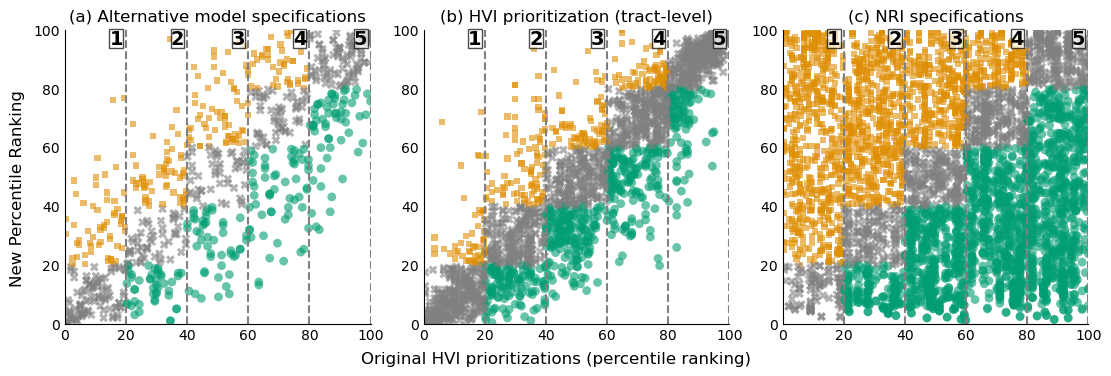

In [576]:
def produce_facet_plot(df_hvi, df_tract_hvi, df_nri, id_vars, filename):
    """Produces main facet plot"""
    print("------------------------")
    print("Producing main facet plot (fig. 2)")
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.65), layout="constrained")

    for i, ax in enumerate(axes):
        ax.axvline(20, color="gray", linestyle="dashed")
        ax.axvline(40, color="gray", linestyle="dashed")
        ax.axvline(60, color="gray", linestyle="dashed")
        ax.axvline(80, color="gray", linestyle="dashed")
        ax.axvline(100, color="gray", linestyle="dashed")

        if i == 0:
            produce_scatter(df_hvi, id_vars[i], ax)
            ax.set_title("(a) Alternative model specifications")
        elif i == 1:
            produce_scatter(df_tract_hvi, id_vars[i], ax)
            ax.set_title("(b) HVI prioritization (tract-level)")
        elif i == 2:
            produce_scatter(df_nri, id_vars[2], ax)
            ax.set_title("(c) NRI specifications")
        default_plot(ax)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xlim((0, 100))
        ax.set_ylim((0, 100))

        ax.text(
            19,
            95,
            "1",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
        ax.text(
            39,
            95,
            "2",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
        ax.text(
            59,
            95,
            "3",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
        ax.text(
            79,
            95,
            "4",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
        ax.text(
            99,
            95,
            "5",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )

    fig.supylabel("New Percentile Ranking")
    fig.supxlabel("Original HVI prioritizations (percentile ranking)")

    plt.savefig(f"./_figures/{filename}", dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()


produce_facet_plot(
    gdf_nta_hvi_plt,
    gdf_tract_hvi_plt,
    gdf_nri_plt,
    ["HVI_raw", "HVI_nta_orig", "HVI_raw"],
    "lineplots_faceted.pdf",
)